# Práctica NLP: Representaciones Vectoriales de Palabras (Word2Vec)

**Objetivo:** Explorar y comparar las representaciones vectoriales de palabras para entender las similitudes y diferencias en cómo se representan las relaciones semánticas y sintácticas del lenguaje.

## 1. Preparación del Entorno

Instalamos las librerías necesarias para el análisis:
- **gensim**: para cargar y trabajar con modelos Word2Vec.
- **scikit-learn**: para reducción de dimensionalidad (PCA, t-SNE).
- **matplotlib**: para visualización.
- **numpy**: para operaciones con vectores.

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.1 MB/s eta 0:00:00


In [2]:
# Importaciones principales
import gensim
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

print(f"Versión de Gensim: {gensim.__version__}")
print("Librerías importadas correctamente ✓")

Versión de Gensim: 4.4.0
Librerías importadas correctamente ✓


### Descarga del Modelo Pre-entrenado

Utilizamos el modelo **`word2vec-google-news-300`** (entrenado sobre Google News, 300 dimensiones) disponible directamente a través de la API de Gensim.

> ⚠️ **Nota:** Este modelo ocupa ~1.7 GB. La primera descarga puede tardar varios minutos. También puedes usar `glove-wiki-gigaword-100` (más ligero) como alternativa.

In [3]:
# Ver modelos disponibles en Gensim
print("Modelos pre-entrenados disponibles en Gensim:")
print(list(api.info()['models'].keys()))

Modelos pre-entrenados disponibles en Gensim:
['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [4]:
# Descargar y cargar el modelo pre-entrenado
# Opción 1: word2vec-google-news-300 (inglés, grande ~1.7 GB)
# Opción 2: glove-wiki-gigaword-100 (inglés, ligero ~130 MB)

print("Descargando modelo... (esto puede tardar unos minutos)")
modelo = api.load('word2vec-google-news-300')
print("Modelo cargado correctamente ✓")
print(f"Vocabulario: {len(modelo.key_to_index):,} palabras")
print(f"Dimensiones del vector: {modelo.vector_size}")

Descargando modelo... (esto puede tardar unos minutos)
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Modelo cargado correctamente ✓
Vocabulario: 3,000,000 palabras
Dimensiones del vector: 300


---
## 2. Toma de Contacto con Gensim

Exploramos la API básica de Gensim para acceder a los vectores de palabras.

In [5]:
# Obtener el vector de una palabra
vector_king = modelo['king']
print(f"Tipo: {type(vector_king)}")
print(f"Forma del vector: {vector_king.shape}")
print(f"Primeras 10 dimensiones del vector de 'king':")
print(vector_king[:10])

Tipo: <class 'numpy.ndarray'>
Forma del vector: (300,)
Primeras 10 dimensiones del vector de 'king':
[ 0.12597656  0.02978516  0.00860596  0.13964844 -0.02563477 -0.03613281
  0.11181641 -0.19824219  0.05126953  0.36328125]


In [6]:
# Comprobar si una palabra está en el vocabulario
palabras_prueba = ['king', 'queen', 'science', 'technology', 'python', 'xyz123abc']

print("Verificación de palabras en el vocabulario:")
for palabra in palabras_prueba:
    en_vocab = palabra in modelo.key_to_index
    print(f"  '{palabra}': {'✓' if en_vocab else '✗'}")

Verificación de palabras en el vocabulario:
  'king': ✓
  'queen': ✓
  'science': ✓
  'technology': ✓
  'python': ✓
  'xyz123abc': ✗


In [24]:
# Similitud entre dos palabras
similitud = modelo.similarity('king', 'queen')
print(f"Similitud entre 'king' y 'queen': {similitud:.4f}")

similitud2 = modelo.similarity('king', 'car')
print(f"Similitud entre 'king' y 'car': {similitud2:.4f}")

similitud3 = modelo.similarity('hot', 'cold')
print(f"Similitud entre 'hot' y 'cold': {similitud3:.4f}")

Similitud entre 'king' y 'queen': 0.6511
Similitud entre 'king' y 'car': 0.0619
Similitud entre 'hot' y 'cold': 0.4602


---
## 3. Análisis Exploratorio

Seleccionamos un conjunto de palabras temáticas para analizar sus representaciones vectoriales y comparar sus similitudes.

In [8]:
# Conjunto de palabras para análisis exploratorio
palabras_analisis = ['science', 'art', 'technology', 'music', 'politics', 'economy']

print("Vectores de palabras temáticas (primeras 5 dimensiones):")
print("-" * 60)
for palabra in palabras_analisis:
    if palabra in modelo.key_to_index:
        vector = modelo[palabra]
        print(f"{palabra:15s}: {vector[:5]}")
    else:
        print(f"{palabra:15s}: ✗ No encontrada en el vocabulario")

Vectores de palabras temáticas (primeras 5 dimensiones):
------------------------------------------------------------
science        : [ 0.0090332   0.12158203  0.3984375   0.21386719 -0.01672363]
art            : [ 0.02331543 -0.06396484  0.00552368  0.21484375 -0.06640625]
technology     : [ 0.04345703  0.00183105  0.18457031  0.00671387 -0.11376953]
music          : [ 0.03881836 -0.21679688 -0.0534668   0.03881836 -0.07714844]
politics       : [ 0.15625     0.02893066 -0.0559082   0.19140625 -0.01263428]
economy        : [ 0.18847656 -0.0703125  -0.16113281  0.03857422 -0.04956055]


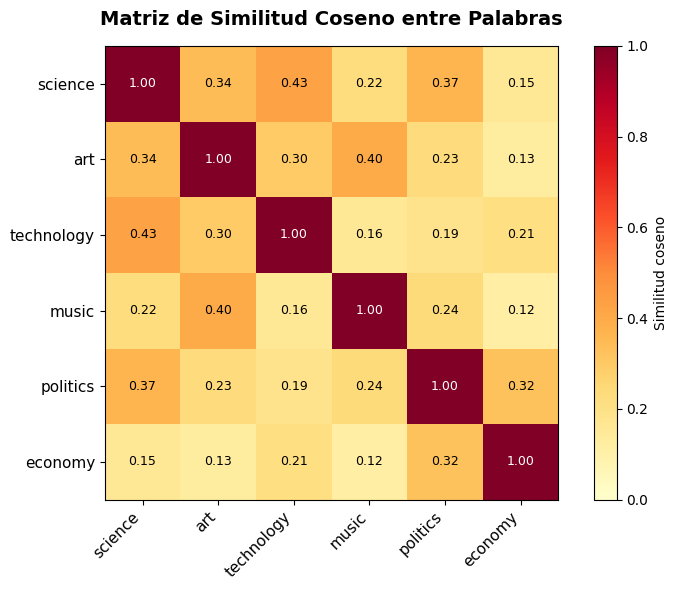

In [9]:
# Matriz de similitud entre pares de palabras
import numpy as np

n = len(palabras_analisis)
matriz_similitud = np.zeros((n, n))

for i, p1 in enumerate(palabras_analisis):
    for j, p2 in enumerate(palabras_analisis):
        if p1 in modelo.key_to_index and p2 in modelo.key_to_index:
            matriz_similitud[i][j] = modelo.similarity(p1, p2)

# Visualización de la matriz de similitud
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matriz_similitud, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(palabras_analisis, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(palabras_analisis, fontsize=11)
plt.colorbar(im, label='Similitud coseno')

# Añadir valores de similitud en cada celda
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{matriz_similitud[i][j]:.2f}",
                ha='center', va='center', fontsize=9,
                color='black' if matriz_similitud[i][j] < 0.7 else 'white')

ax.set_title('Matriz de Similitud Coseno entre Palabras', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 4. Tareas Específicas

### 4.1 Analogías

Las analogías en Word2Vec se resuelven mediante operaciones vectoriales:

> **"París es a Francia lo que Tokio es a ¿qué?"**  
> → `vector(Paris) - vector(France) + vector(Tokyo) ≈ vector(Japan)`

Gensim permite resolver esto con `most_similar(positive=[...], negative=[...])`.

In [10]:
# Función auxiliar para mostrar analogías
def resolver_analogia(a, b, c, modelo, top_n=5):
    """
    Resuelve la analogía: 'a es a b como c es a ?'
    Usando la operación: vector(b) - vector(a) + vector(c)
    """
    print(f"  Analogía: '{a}' → '{b}' | '{c}' → ?")
    try:
        resultado = modelo.most_similar(positive=[b, c], negative=[a], topn=top_n)
        print(f"  Resultado top-{top_n}:")
        for palabra, similitud in resultado:
            print(f"    {palabra:20s}: {similitud:.4f}")
    except KeyError as e:
        print(f"  ✗ Error: palabra no encontrada → {e}")
    print()

In [11]:
print("=" * 60)
print("RESOLUCIÓN DE ANALOGÍAS")
print("=" * 60)

# Analogía geográfica: París es a Francia como Tokio es a...
print("\n📍 Analogías geográficas:")
resolver_analogia('Paris', 'France', 'Tokyo', modelo)
resolver_analogia('Madrid', 'Spain', 'Rome', modelo)

# Analogía de género: rey es a hombre como reina es a...
print("\n👑 Analogías de género (el famoso ejemplo king-man+woman):")
resolver_analogia('man', 'king', 'woman', modelo)
resolver_analogia('boy', 'prince', 'girl', modelo)

# Analogía semántica: grande es a pequeño como rápido es a...
print("\n🔤 Analogías semánticas:")
resolver_analogia('big', 'small', 'fast', modelo)
resolver_analogia('doctor', 'hospital', 'teacher', modelo)

RESOLUCIÓN DE ANALOGÍAS

📍 Analogías geográficas:
  Analogía: 'Paris' → 'France' | 'Tokyo' → ?
  Resultado top-5:
    Japan               : 0.8168
    Japanese            : 0.6481
    South_Korea         : 0.6142
    Japans              : 0.6117
    Shizuoka            : 0.5742

  Analogía: 'Madrid' → 'Spain' | 'Rome' → ?
  Resultado top-5:
    Italy               : 0.7005
    Sicily              : 0.5927
    Greece              : 0.5306
    defeated_Andreas_Seppi: 0.4920
    Sardinia            : 0.4894


👑 Analogías de género (el famoso ejemplo king-man+woman):
  Analogía: 'man' → 'king' | 'woman' → ?
  Resultado top-5:
    queen               : 0.7118
    monarch             : 0.6190
    princess            : 0.5902
    crown_prince        : 0.5499
    prince              : 0.5377

  Analogía: 'boy' → 'prince' | 'girl' → ?
  Resultado top-5:
    princess            : 0.7422
    duchess             : 0.6355
    monarch             : 0.6182
    princes             : 0.6174
    queen  

### Palabras más Similares

Identificamos las palabras del vocabulario cuyo vector es más cercano (mayor similitud coseno) al de un término dado.

In [12]:
# Palabras más similares a un término
terminos = ['king', 'computer', 'football', 'music', 'war']

print("=" * 60)
print("PALABRAS MÁS SIMILARES")
print("=" * 60)

for termino in terminos:
    print(f"\n🔎 Palabras más similares a '{termino}':")
    similares = modelo.most_similar(termino, topn=8)
    for i, (palabra, score) in enumerate(similares, 1):
        barra = '█' * int(score * 20)
        print(f"  {i:2d}. {palabra:20s} {score:.4f}  {barra}")

PALABRAS MÁS SIMILARES

🔎 Palabras más similares a 'king':
   1. kings                0.7138  ██████████████
   2. queen                0.6511  █████████████
   3. monarch              0.6413  ████████████
   4. crown_prince         0.6204  ████████████
   5. prince               0.6160  ████████████
   6. sultan               0.5865  ███████████
   7. ruler                0.5798  ███████████
   8. princes              0.5647  ███████████

🔎 Palabras más similares a 'computer':
   1. computers            0.7979  ███████████████
   2. laptop               0.6640  █████████████
   3. laptop_computer      0.6549  █████████████
   4. Computer             0.6473  ████████████
   5. com_puter            0.6082  ████████████
   6. technician_Leonard_Luchko 0.5663  ███████████
   7. mainframes_minicomputers 0.5618  ███████████
   8. laptop_computers     0.5585  ███████████

🔎 Palabras más similares a 'football':
   1. soccer               0.7314  ██████████████
   2. fooball              0.714

In [13]:
# El intruso: encontrar la palabra que no encaja
print("=" * 60)
print("ENCUENTRA EL INTRUSO (doesnt_match)")
print("=" * 60)

grupos = [
    ['breakfast', 'cereal', 'dinner', 'lunch'],
    ['cat', 'dog', 'bird', 'car'],
    ['football', 'tennis', 'basketball', 'violin'],
]

for grupo in grupos:
    intruso = modelo.doesnt_match(grupo)
    print(f"\n  Grupo: {grupo}")
    print(f"  → Intruso detectado: '{intruso}'")

ENCUENTRA EL INTRUSO (doesnt_match)

  Grupo: ['breakfast', 'cereal', 'dinner', 'lunch']
  → Intruso detectado: 'cereal'

  Grupo: ['cat', 'dog', 'bird', 'car']
  → Intruso detectado: 'car'

  Grupo: ['football', 'tennis', 'basketball', 'violin']
  → Intruso detectado: 'violin'


### Divergencias

Exploraremos ejemplos de palabras cuyas representaciones vectoriales son notablemente diferentes, es decir, tienen baja similitud coseno.

In [14]:
# Calcular palabras más DISTANTES (menor similitud)
def palabras_menos_similares(palabra, modelo, candidatos, top_n=5):
    """Encuentra palabras con menor similitud coseno a la palabra dada."""
    similitudes = [(c, modelo.similarity(palabra, c)) for c in candidatos if c in modelo.key_to_index]
    similitudes.sort(key=lambda x: x[1])
    return similitudes[:top_n]

# Conjunto de palabras candidatas para comparar
candidatos = ['car', 'music', 'football', 'science', 'ocean', 'mountain',
              'philosophy', 'computer', 'flower', 'soldier', 'economy', 'art']

terminos_divergencia = ['king', 'computer']

print("=" * 60)
print("DIVERGENCIAS: PALABRAS MÁS DISTANTES")
print("=" * 60)

for termino in terminos_divergencia:
    print(f"\n📉 Palabras más distantes de '{termino}' (menor similitud):")
    distantes = palabras_menos_similares(termino, modelo, candidatos)
    for palabra, score in distantes:
        print(f"  {palabra:20s}: {score:.4f}")

    print(f"\n📈 Palabras más similares a '{termino}' (mayor similitud):")
    similares = palabras_menos_similares.__wrapped__ = None  # reset
    for palabra, score in sorted([(c, modelo.similarity(termino, c))
                                   for c in candidatos if c in modelo.key_to_index],
                                  key=lambda x: -x[1])[:5]:
        print(f"  {palabra:20s}: {score:.4f}")

DIVERGENCIAS: PALABRAS MÁS DISTANTES

📉 Palabras más distantes de 'king' (menor similitud):
  science             : -0.0084
  computer            : 0.0275
  philosophy          : 0.0315
  car                 : 0.0619
  ocean               : 0.0653

📈 Palabras más similares a 'king' (mayor similitud):
  mountain            : 0.1685
  flower              : 0.1671
  soldier             : 0.1408
  economy             : 0.1111
  art                 : 0.0929

📉 Palabras más distantes de 'computer' (menor similitud):
  mountain            : 0.0300
  flower              : 0.0778
  soldier             : 0.0806
  philosophy          : 0.0919
  ocean               : 0.1252

📈 Palabras más similares a 'computer' (mayor similitud):
  computer            : 1.0000
  science             : 0.3110
  music               : 0.2513
  car                 : 0.2461
  art                 : 0.2423


In [15]:
# Comparación directa de similitudes para ilustrar divergencias
pares = [
    ('king', 'queen'),
    ('king', 'ocean'),
    ('doctor', 'nurse'),
    ('doctor', 'guitar'),
    ('Paris', 'London'),
    ('Paris', 'carrot'),
    ('war', 'peace'),
    ('war', 'bicycle'),
]

print("=" * 60)
print("COMPARACIÓN DE SIMILITUDES")
print("=" * 60)
print(f"{'Par de palabras':<30} {'Similitud':>10}")
print("-" * 45)
for w1, w2 in pares:
    try:
        sim = modelo.similarity(w1, w2)
        barra = '█' * int(sim * 25)
        print(f"  '{w1}' ↔ '{w2}': {sim:6.4f}  {barra}")
    except KeyError:
        print(f"  '{w1}' ↔ '{w2}': palabra no en vocabulario")

COMPARACIÓN DE SIMILITUDES
Par de palabras                 Similitud
---------------------------------------------
  'king' ↔ 'queen': 0.6511  ████████████████
  'king' ↔ 'ocean': 0.0653  █
  'doctor' ↔ 'nurse': 0.6320  ███████████████
  'doctor' ↔ 'guitar': 0.0775  █
  'Paris' ↔ 'London': 0.5290  █████████████
  'Paris' ↔ 'carrot': -0.0052  
  'war' ↔ 'peace': 0.3408  ████████
  'war' ↔ 'bicycle': 0.0652  █


---
## 5. Visualización con t-SNE

Utilizamos la técnica de reducción de dimensionalidad **t-SNE** (t-Distributed Stochastic Neighbor Embedding) para proyectar los vectores de alta dimensión (300D) en un espacio 2D visualizable. También comparamos con **PCA**.

> ℹ️ **t-SNE** preserva las distancias locales entre puntos, siendo ideal para visualizar clusters semánticos. **PCA** es más rápida y preserva la varianza global.

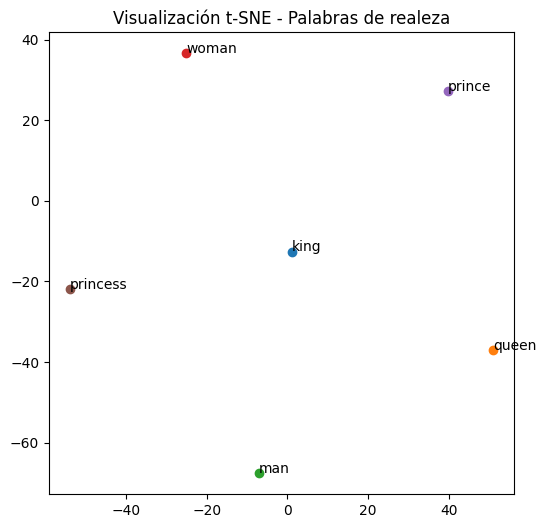

In [18]:
# ============================================================
# Código proporcionado en la práctica (adaptado)
# ============================================================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Lista de palabras a visualizar
palabras = ['king', 'queen', 'man', 'woman', 'prince', 'princess']
vectores = np.array([modelo[palabra] for palabra in palabras])  # array NumPy requerido por TSNE

# Reducción de dimensionalidad con t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vectores_2d = tsne.fit_transform(vectores)

# Gráfica básica (código original de la práctica)
plt.figure(figsize=(6, 6))
for punto, palabra in zip(vectores_2d, palabras):
    plt.scatter(punto[0], punto[1])
    plt.text(punto[0] + 0.02, punto[1] + 0.02, palabra)
plt.title('Visualización t-SNE - Palabras de realeza')
plt.show()

In [19]:
# ============================================================
# Visualización mejorada con grupos semánticos y colores
# ============================================================

# Grupos semánticos de palabras
grupos = {
    'Realeza': {'palabras': ['king', 'queen', 'prince', 'princess', 'throne', 'crown'],
                'color': '#E74C3C'},
    'Tecnología': {'palabras': ['computer', 'software', 'internet', 'algorithm', 'robot'],
                   'color': '#3498DB'},
    'Naturaleza': {'palabras': ['ocean', 'mountain', 'forest', 'river', 'sky'],
                   'color': '#2ECC71'},
    'Música': {'palabras': ['music', 'guitar', 'piano', 'song', 'melody'],
               'color': '#F39C12'},
    'Deporte': {'palabras': ['football', 'basketball', 'tennis', 'sport', 'athlete'],
                'color': '#9B59B6'},
}

# Recopilar todas las palabras y vectores
todas_palabras = []
todos_vectores = []
colores = []
etiquetas_grupos = []

for grupo, info in grupos.items():
    for palabra in info['palabras']:
        if palabra in modelo.key_to_index:
            todas_palabras.append(palabra)
            todos_vectores.append(modelo[palabra])
            colores.append(info['color'])
            etiquetas_grupos.append(grupo)

X = np.array(todos_vectores)

# Aplicar t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(todas_palabras)-1), n_iter=1000)
X_tsne = tsne.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f"Total de palabras visualizadas: {len(todas_palabras)}")
print(f"Varianza explicada por PCA: {pca.explained_variance_ratio_.sum():.2%}")

Total de palabras visualizadas: 26
Varianza explicada por PCA: 27.23%


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


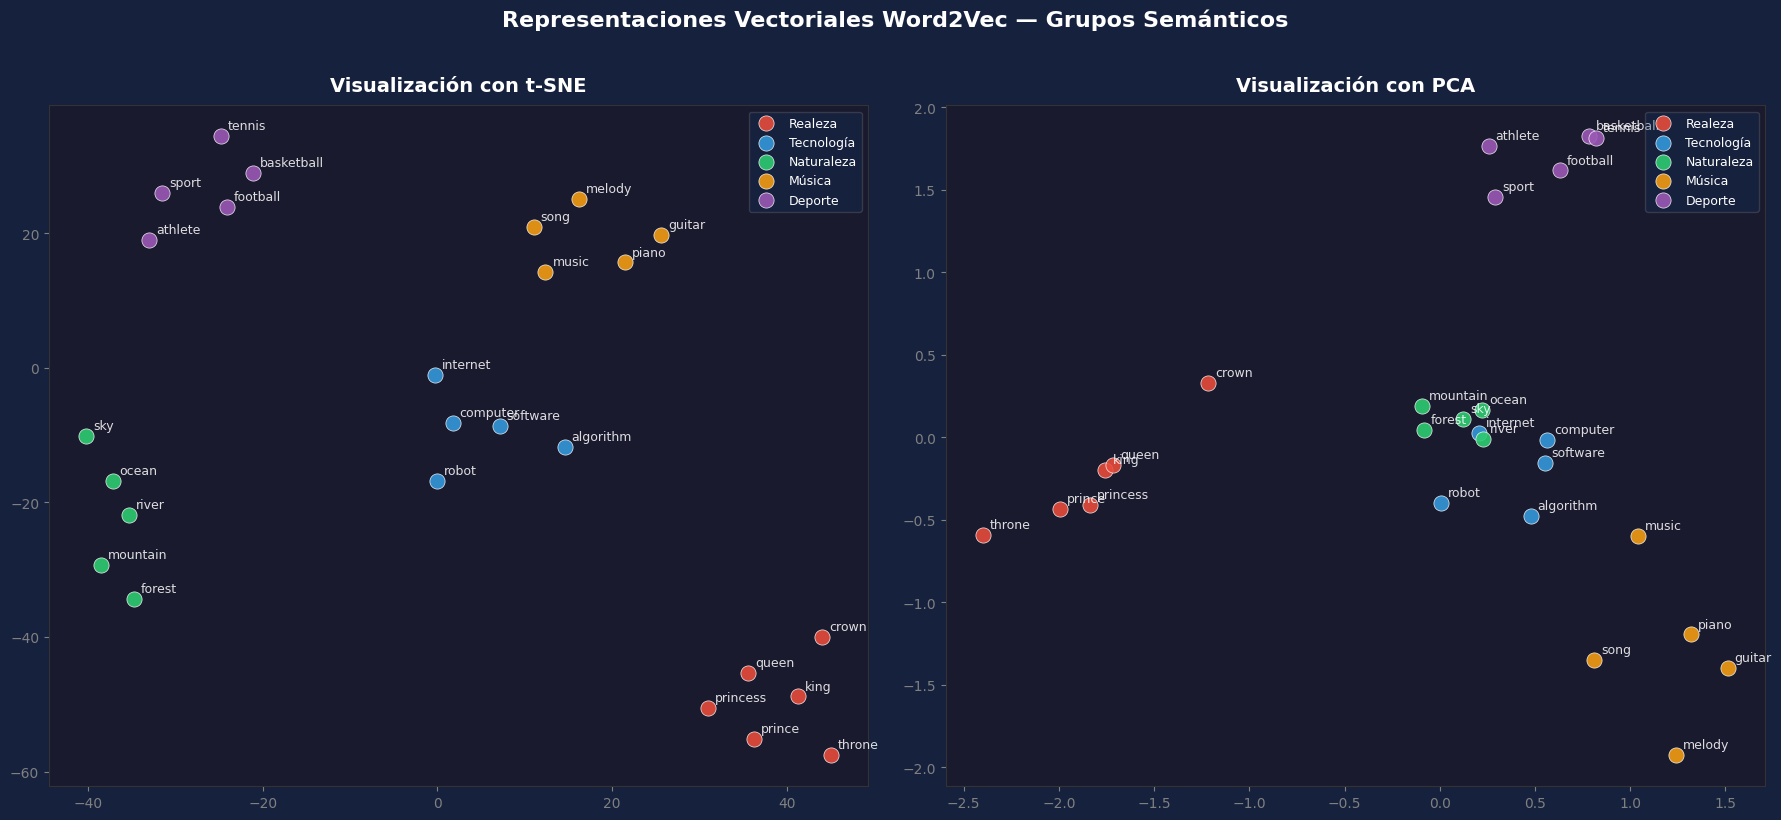

In [20]:
# Visualización comparativa t-SNE vs PCA
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, coords, titulo in zip(axes, [X_tsne, X_pca], ['t-SNE', 'PCA']):
    # Fondo oscuro para mejor contraste
    ax.set_facecolor('#1A1A2E')
    fig.patch.set_facecolor('#16213E')

    # Scatter plot por grupo
    for grupo, info in grupos.items():
        idx = [i for i, g in enumerate(etiquetas_grupos) if g == grupo]
        if idx:
            ax.scatter(
                coords[idx, 0], coords[idx, 1],
                c=info['color'], s=120, alpha=0.9,
                label=grupo, edgecolors='white', linewidth=0.5, zorder=3
            )

    # Etiquetas de palabras
    for i, (palabra, color) in enumerate(zip(todas_palabras, colores)):
        ax.annotate(
            palabra,
            xy=(coords[i, 0], coords[i, 1]),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            color='white',
            alpha=0.85,
            fontweight='medium'
        )

    ax.set_title(f'Visualización con {titulo}', color='white', fontsize=14, fontweight='bold', pad=10)
    ax.tick_params(colors='gray')
    ax.spines['bottom'].set_color('#333333')
    ax.spines['top'].set_color('#333333')
    ax.spines['left'].set_color('#333333')
    ax.spines['right'].set_color('#333333')

    legend = ax.legend(loc='upper right', framealpha=0.3, facecolor='#0F3460',
                       edgecolor='gray', fontsize=9, labelcolor='white')

plt.suptitle('Representaciones Vectoriales Word2Vec — Grupos Semánticos',
             color='white', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

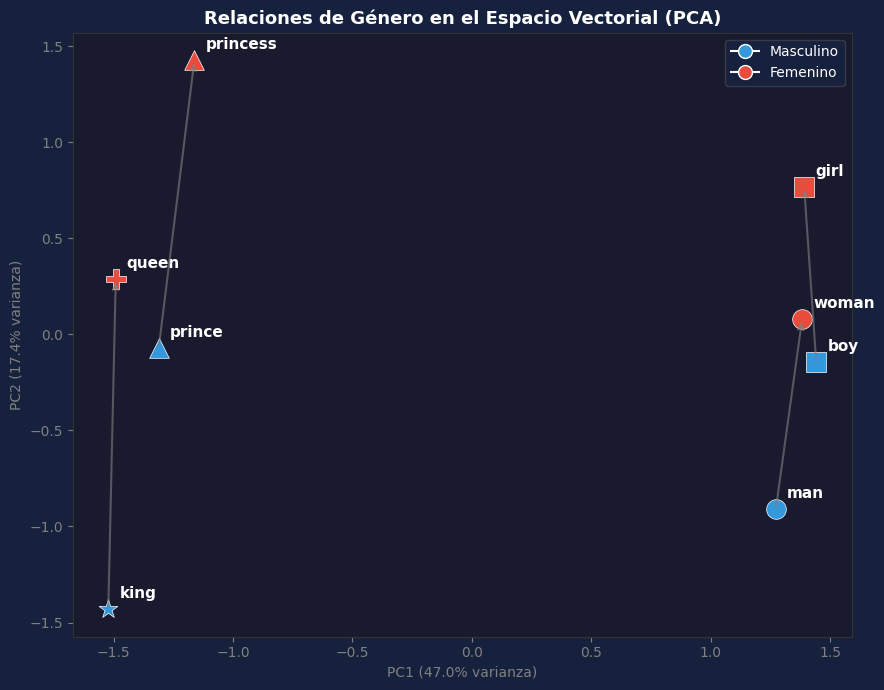

In [25]:
# ============================================================
# Visualización adicional: Relaciones vectoriales king-man+woman
# ============================================================

# Palabras de la analogía clásica
palabras_analogia = ['king', 'queen', 'man', 'woman', 'prince', 'princess', 'boy', 'girl']
#                     masc    fem      masc   fem      masc      fem         masc   fem
colores_analogia  = ['#3498DB', '#E74C3C', '#3498DB', '#E74C3C', '#3498DB', '#E74C3C', '#3498DB', '#E74C3C']
marcadores = ['*', 'P', 'o', 'o', '^', '^', 's', 's']

vectores_analogia = [modelo[p] for p in palabras_analogia]
X_analogia = np.array(vectores_analogia)

# Reducción con PCA (más estable con pocos puntos)
pca2 = PCA(n_components=2)
X_analogia_2d = pca2.fit_transform(X_analogia)

fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('#1A1A2E')
fig.patch.set_facecolor('#16213E')

for i, (p, c, m) in enumerate(zip(palabras_analogia, colores_analogia, marcadores)):
    ax.scatter(X_analogia_2d[i, 0], X_analogia_2d[i, 1],
               c=c, s=200, marker=m, edgecolors='white', linewidth=0.5, zorder=3)
    ax.annotate(p, xy=(X_analogia_2d[i, 0], X_analogia_2d[i, 1]),
                xytext=(8, 8), textcoords='offset points',
                color='white', fontsize=11, fontweight='bold')

# Flechas que muestran la relación vectorial (masculino → femenino)
rel = {'king': 'queen', 'man': 'woman', 'prince': 'princess', 'boy': 'girl'}
idx_map = {p: i for i, p in enumerate(palabras_analogia)}

for p1, p2 in rel.items():
    i, j = idx_map[p1], idx_map[p2]
    ax.annotate('', xy=X_analogia_2d[j], xytext=X_analogia_2d[i],
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, alpha=0.6))

ax.set_title('Relaciones de Género en el Espacio Vectorial (PCA)',
             color='white', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} varianza)', color='gray')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} varianza)', color='gray')
ax.tick_params(colors='gray')
for spine in ax.spines.values():
    spine.set_color('#333333')

# Leyenda manual
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498DB', markersize=10, label='Masculino'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E74C3C', markersize=10, label='Femenino'),
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.3,
          facecolor='#0F3460', edgecolor='gray', labelcolor='white')

plt.tight_layout()
plt.show()

---
## 6. Conclusiones

En esta práctica hemos explorado los modelos de representación vectorial de palabras (Word2Vec) a través de Gensim:

| Aspecto | Observación |
|---------|-------------|
| **Similitud semántica** | Las palabras relacionadas semánticamente tienen vectores con alta similitud coseno (ej. *king* ↔ *queen*) |
| **Analogías** | Las operaciones aritméticas sobre vectores capturan relaciones lingüísticas (género, geografía) |
| **Divergencias** | Palabras de dominios distintos presentan baja similitud, reflejando diferencias conceptuales |
| **Visualización** | t-SNE agrupa palabras semánticamente relacionadas en el espacio 2D, mientras PCA captura la varianza global |

### Reflexiones finales
- Los modelos Word2Vec capturan relaciones **sintácticas y semánticas** de forma implícita.
- La **similitud coseno** es una métrica adecuada para medir la proximidad entre vectores de palabras.
- Las **visualizaciones** confirman que las palabras de un mismo campo semántico tienden a agruparse en el espacio vectorial.
- El rendimiento depende del **corpus de entrenamiento**: Google News captura bien el inglés formal, pero puede no representar adecuadamente otros idiomas o dominios especializados.